# 得点発生時点の実力差（final_points）別・得点間の待ち時間の経験的分析

`statsbomb_data` 以下の全リーグ・全シーズンの `*_goals_and_red_cards.csv` を対象に、

- **得点したチームから見た「実力差」**（`final_points` に基づく単純差分。試合全体で一定値）ごとに、
- **直前の得点（どちらのチームによるものでも良い。最初の得点はキックオフ t=0）から
  その得点が入るまでの待ち時間（分）**

の分布をヒストグラムにする（`score_difference.ipynb` / `recent_score.ipynb` と同じ
「共通ビン＋平均・中央値・最頻値・分散・標準偏差オーバーレイ」の描画仕様）。実力差が待ち時間に
寄与しているかを確かめるための、最初の一歩となる粗い（"えいやで"の）分析。

- 入力：`statsbomb_data/**/*_goals_and_red_cards.csv`（全リーグ・全シーズン）
- 出力：
  - 得点イベント単位のテーブル `goal_events_skill_gap.csv`（本ノートブックの中間生成物）
  - 異常値をまとめたテーブル `goal_events_anomalies.csv`（存在する場合のみ）
  - 実力差の区分ごとの待ち時間ヒストグラム画像 `figures/goal_waiting_time_by_skill_gap.png`


## データ形式・実力差（skill gap）の定義

`goals_and_red_cards.csv` の1行は「得点」または「退場」イベント（+試合ごとのプレースホルダー行）。
本分析で使うのは得点イベントの行のみ（`red_card` が欠損かつ `home_away` が非欠損の行）。

用いる主なカラム：

| 列名 | 内容 |
|---|---|
| `match_id` | 試合ID（`league_code`, `season_name` と組み合わせて一意に試合を識別） |
| `home_away` | 得点したチーム（0=home, 1=away） |
| `minute` / `second` | 得点した試合クロック時刻（前半・後半を通して連続的に増加する分・秒） |
| `home_final_points` / `away_final_points` | そのシーズン終了時点の home / away チームの累積勝ち点 |
| `home_provisional_points` / `away_provisional_points` | その試合開始時点（＝それまでの試合）での累積勝ち点。**今回は未使用**（暫定勝ち点をどの試合数から信頼するかは別途検討のため） |

**実力差（skill gap）の定義（今回は final のみ・単純差分）**

$$
\text{home\_team\_skill\_gap} = \text{home\_final\_points} - \text{away\_final\_points}, \qquad
\text{away\_team\_skill\_gap} = -\,\text{home\_team\_skill\_gap}
$$

試合全体で一定値（`final_points` はシーズン終了時点の値で、試合ごとに変わらない）。
各得点イベントには、**得点したチーム自身の視点の実力差**
（`home_away==0` なら `home_team_skill_gap`、`home_away==1` なら `away_team_skill_gap`）を
`skill_gap` として付与する。プラスが大きいほど「格上が得点した」、マイナスが大きいほど
「格下が得点した」ことを意味する。


In [2]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフ内の日本語（タイトル・軸ラベル等）が文字化けしないよう日本語フォントを指定する。
# 手元（macOS）では "Hiragino Sans" が使われ、それが無い環境では
# 順にフォールバックして "Noto Sans CJK JP" 等が使われる。
# （Windows等、別環境で開く場合は "Meiryo" や "Yu Gothic" などお使いの環境にあるフォント名を
#  リストの先頭に追加してください）
plt.rcParams["font.family"] = ["Hiragino Sans", "Noto Sans CJK JP", "Yu Gothic", "Meiryo", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False


## 1. 全リーグ・全シーズンのデータを読み込む

`match_id` はデータセット全体で一意であることを確認済みだが、念のため
`league_code, season_name, match_id` の組をキーとして試合を識別する（`score_difference.ipynb` と同様）。


In [3]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")
print(f"対象リーグ: {sorted(df_all['league_code'].unique())}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461
対象リーグ: ['FB', 'ISL', 'L1', 'LF', 'LL', 'PL', 'SA', 'WSL']


## 2. 試合ごとに「実力差（final_points）」と「得点までの待ち時間」を計算する

試合ごとに得点イベントを時刻順に並べ、各得点について

- `home_team_skill_gap` / `away_team_skill_gap`: `final_points` の単純差分（試合全体で一定）
- `skill_gap`: 得点したチーム自身の視点の実力差（上記のどちらかを `home_away` で選択）
- `goal_number`: その試合の中で何番目の得点か（1始まり）
- `waiting_time`: 直前の得点（試合最初の得点なら試合開始 t=0）からこの得点までの経過時間（分）

を記録する。退場者の行は無視する（得点イベントのみを対象とする）。


In [4]:
def build_goal_events(df):
    """
    goals_and_red_cards の df（複数リーグ・シーズンを結合したものでも可）から、
    得点イベントごとの実力差（home/away/得点者視点）と
    waiting_time（直前の得点からの経過時間・分）を計算する。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    goal_rows["home_team_skill_gap"] = goal_rows["home_final_points"] - goal_rows["away_final_points"]
    goal_rows["away_team_skill_gap"] = -goal_rows["home_team_skill_gap"]

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        prev_t = 0.0  # 試合開始（キックオフ）
        for i, row in enumerate(g.itertuples(index=False), start=1):
            t = row.time_min
            skill_gap = row.home_team_skill_gap if row.home_away == 0 else row.away_team_skill_gap
            records.append({
                "league_code": league_code,
                "season_name": season_name,
                "match_id": match_id,
                "match_date": row.match_date,
                "home_team": row.home_team,
                "away_team": row.away_team,
                "scoring_team": row.scoring_team,
                "home_away": row.home_away,
                "goal_number": i,
                "home_team_skill_gap": row.home_team_skill_gap,
                "away_team_skill_gap": row.away_team_skill_gap,
                "skill_gap": skill_gap,
                "goal_time_min": t,
                "waiting_time": t - prev_t,
            })
            prev_t = t

    return pd.DataFrame(records)


events_df = build_goal_events(df_all)
print(f"得点イベント数: {len(events_df)}")
print(events_df.head().to_string())


得点イベント数: 6964
  league_code season_name  match_id  match_date     home_team         away_team      scoring_team  home_away  goal_number  home_team_skill_gap  away_team_skill_gap  skill_gap  goal_time_min  waiting_time
0          FB   2023/2024   3910730  2023-09-15   SC Freiburg  Bayern München W       SC Freiburg          0            1                  -36                   36        -36       6.000000      6.000000
1          FB   2023/2024   3910730  2023-09-15   SC Freiburg  Bayern München W  Bayern München W          1            2                  -36                   36         36      20.100000     14.100000
2          FB   2023/2024   3910730  2023-09-15   SC Freiburg  Bayern München W  Bayern München W          1            3                  -36                   36         36      89.866667     69.766667
3          FB   2023/2024   3910730  2023-09-15   SC Freiburg  Bayern München W       SC Freiburg          0            4                  -36                   36       

## 3. 異常値のチェック・分離

以下の観点で異常なレコードをチェックし、見つかった場合は分析対象から外して
別テーブル `goal_events_anomalies.csv` にまとめる（現時点のデータでは 0 件だが、
リーグ・シーズンを追加した際に備えてチェック自体は残す）。

- `waiting_time <= 0`（得点の時刻の前後関係が崩れている）
- 同一試合内で `goal_time_min` が完全に重複する（同時刻に2得点が記録されている）


In [5]:
anomaly_masks = {}
anomaly_masks["waiting_time_non_positive"] = events_df["waiting_time"] <= 0

dup_time = events_df.duplicated(subset=["league_code", "season_name", "match_id", "goal_time_min"], keep=False)
anomaly_masks["duplicate_goal_time"] = dup_time

is_anomaly = np.zeros(len(events_df), dtype=bool)
for name, mask in anomaly_masks.items():
    print(f"- {name}: {mask.sum()} 件")
    is_anomaly |= mask.values

anomalies_df = events_df.loc[is_anomaly].copy()
clean_events_df = events_df.loc[~is_anomaly].copy()

print(f"異常値として分離した件数: {len(anomalies_df)}")
print(f"分析に使う得点イベント数: {len(clean_events_df)}")

if len(anomalies_df) > 0:
    anomalies_df.to_csv("goal_events_anomalies.csv", index=False)
    print("-> goal_events_anomalies.csv に保存しました")
else:
    print("-> 異常値は見つからなかったため goal_events_anomalies.csv は作成していません")


- waiting_time_non_positive: 0 件
- duplicate_goal_time: 0 件
異常値として分離した件数: 0
分析に使う得点イベント数: 6964
-> 異常値は見つからなかったため goal_events_anomalies.csv は作成していません


## 4. 得点イベント単位のテーブルを保存する

このテーブル（`match_id`, `home_team_skill_gap`, `away_team_skill_gap`, `skill_gap`,
`waiting_time` 等を含む、得点イベント1行1レコードの形式）を `goal_events_skill_gap.csv` として
保存する。以降の集計・可視化はこのテーブル（`clean_events_df`）を使う。


In [6]:
clean_events_df.to_csv("goal_events_skill_gap.csv", index=False)
print(f"goal_events_skill_gap.csv に {len(clean_events_df)} 行を保存しました")
print(clean_events_df.columns.tolist())


goal_events_skill_gap.csv に 6964 行を保存しました
['league_code', 'season_name', 'match_id', 'match_date', 'home_team', 'away_team', 'scoring_team', 'home_away', 'goal_number', 'home_team_skill_gap', 'away_team_skill_gap', 'skill_gap', 'goal_time_min', 'waiting_time']


## 5. 実力差を区分（ビン）に分ける（暫定・"えいやで"の分割）

ビンの切り方はまだ検討中のため、ひとまず `skill_gap` の分布を7等分位（quantile）で
7つの区分に分け、感覚をつかむことを優先する。境界の選び方（等幅／等分位／リーグ内標準化 等）は
今後見直す前提の**暫定処理**。


In [7]:
N_BINS = 7
clean_events_df["skill_gap_bin"] = pd.qcut(clean_events_df["skill_gap"], q=N_BINS)

SKILL_GAP_BIN_ORDER = list(clean_events_df["skill_gap_bin"].cat.categories)

stats_preview = clean_events_df.groupby("skill_gap_bin", observed=True)["waiting_time"].describe()
print(stats_preview.to_string())


                   count       mean        std       min       25%        50%        75%        max
skill_gap_bin                                                                                      
(-79.001, -13.0]  1045.0  22.644418  18.949890  0.300000  7.700000  16.716667  31.800000  90.216667
(-13.0, -3.0]      986.0  23.756677  19.698981  0.116667  8.183333  18.416667  34.458333  94.783333
(-3.0, 5.0]       1002.0  24.404790  20.646873  0.033333  8.300000  18.291667  36.050000  94.183333
(5.0, 14.0]       1003.0  24.560286  19.985107  0.233333  8.816667  19.066667  34.633333  92.766667
(14.0, 24.0]      1028.0  23.474303  19.582502  0.083333  8.141667  17.966667  34.041667  92.666667
(24.0, 35.0]       933.0  21.271222  17.869350  0.083333  7.283333  16.483333  30.316667  91.783333
(35.0, 79.0]       967.0  20.221148  18.233784  0.416667  6.775000  14.100000  28.708333  92.283333


## 6. ヒストグラムのビン（待ち時間）を共通化する

`score_difference.ipynb` / `recent_score.ipynb` と同様、待ち時間（分）のヒストグラムの
ビン幅は5分刻みとし、7区分すべての最大待ち時間から上限を決めることで、
全パネルで同じビン境界を使う。最頻値は、このヒストグラムのビンの中で度数が最大となる
ビンの中央値として近似的に求める（ビン幅に依存する近似値であることに注意）。


In [8]:
BIN_WIDTH = 5  # 分
max_wait = clean_events_df["waiting_time"].max()
BIN_EDGES = np.arange(0, np.ceil(max_wait / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait:.2f}分 -> ビン境界: 0〜{BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES)-1}ビン）")


最大待ち時間: 94.78分 -> ビン境界: 0〜95分（5分刻み、19ビン）


## 7. 実力差の区分ごとのヒストグラムを1枚の図にまとめて描画・保存する

各パネルに
- 標本数 `n`
- 平均値（実線）
- 中央値（破線）
- 最頻値（点線、上のビンベースの近似値）
- 分散・標準偏差（凡例にテキストのみ表示）

を重ねて表示する。ビン幅・ビン境界は全パネル共通（縦軸のスケールはパネルごとに自動調整）。
図は `figures/goal_waiting_time_by_skill_gap.png` に保存する。


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

保存しました: figures/goal_waiting_time_by_skill_gap.png


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Yu Gothic' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Noto

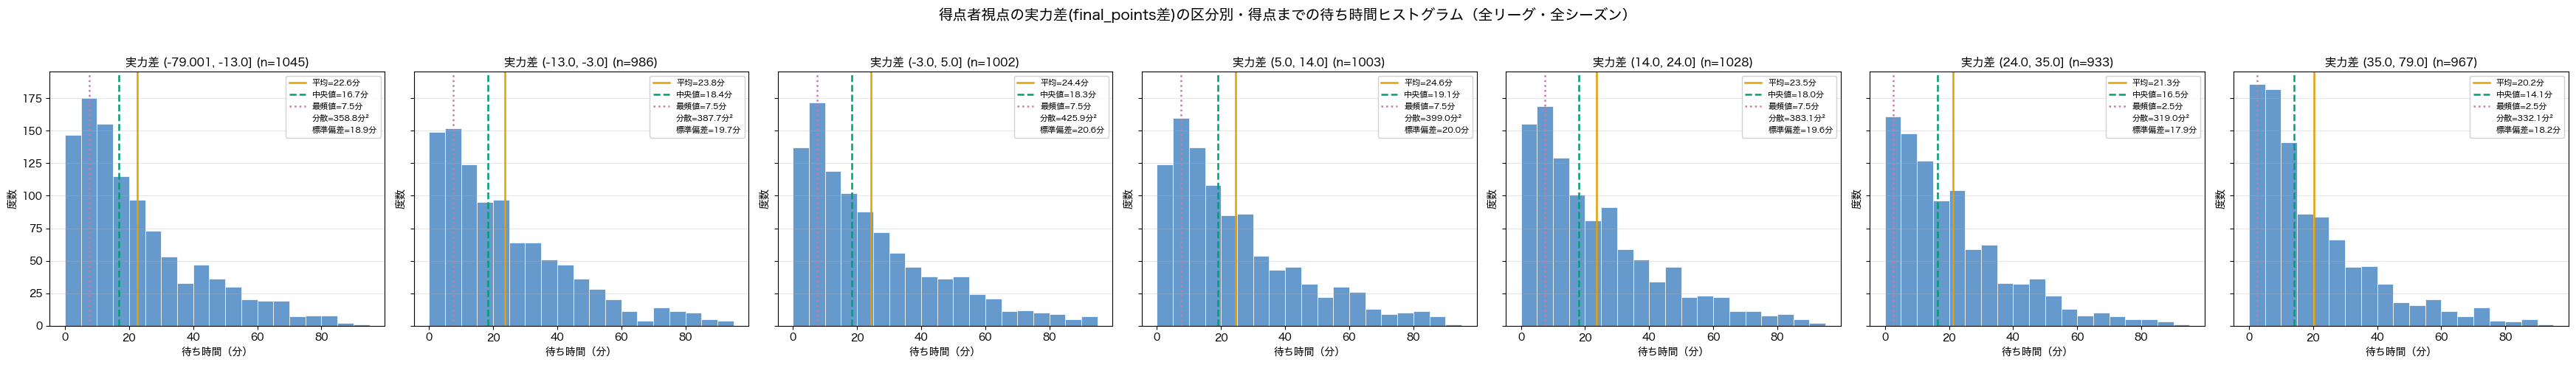

In [9]:
BAR_COLOR = "#6699CC"
MEAN_COLOR = "#E69F00"
MEDIAN_COLOR = "#009E73"
MODE_COLOR = "#CC79A7"


def compute_stats(vals, bin_edges):
    n = len(vals)
    if n == 0:
        return dict(n=0, mean=np.nan, median=np.nan, mode=np.nan, var=np.nan, std=np.nan,
                    counts=np.zeros(len(bin_edges) - 1))
    counts, _ = np.histogram(vals, bins=bin_edges)
    mode_idx = int(np.argmax(counts))
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    return dict(n=n, mean=np.mean(vals), median=np.median(vals), mode=mode_val,
                var=np.var(vals), std=np.std(vals), counts=counts)


def plot_one(ax, vals, title, bin_edges):
    stats = compute_stats(vals, bin_edges)
    ax.bar(bin_edges[:-1], stats["counts"], width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)
    if stats["n"] > 0:
        ax.axvline(stats["mean"], color=MEAN_COLOR, linestyle="-", linewidth=1.8,
                    label=f"平均={stats['mean']:.1f}分")
        ax.axvline(stats["median"], color=MEDIAN_COLOR, linestyle="--", linewidth=1.8,
                    label=f"中央値={stats['median']:.1f}分")
        ax.axvline(stats["mode"], color=MODE_COLOR, linestyle=":", linewidth=1.8,
                    label=f"最頻値={stats['mode']:.1f}分")
        var_handle = Line2D([], [], color="none", label=f"分散={stats['var']:.1f}分²")
        std_handle = Line2D([], [], color="none", label=f"標準偏差={stats['std']:.1f}分")
        handles, labels = ax.get_legend_handles_labels()
        handles += [var_handle, std_handle]
        labels += [var_handle.get_label(), std_handle.get_label()]
        ax.legend(handles, labels, fontsize=8, loc="upper right", framealpha=0.9)
    ax.set_title(f"{title} (n={stats['n']})", fontsize=11)
    ax.set_xlabel("待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)
    return stats


fig, axes = plt.subplots(1, len(SKILL_GAP_BIN_ORDER), figsize=(5 * len(SKILL_GAP_BIN_ORDER), 5), sharey=True)

all_stats = {}
for ax, bin_label in zip(axes, SKILL_GAP_BIN_ORDER):
    vals = clean_events_df.loc[clean_events_df["skill_gap_bin"] == bin_label, "waiting_time"].values
    all_stats[bin_label] = plot_one(ax, vals, f"実力差 {bin_label}", BIN_EDGES)

fig.suptitle("得点者視点の実力差(final_points差)の区分別・得点までの待ち時間ヒストグラム（全リーグ・全シーズン）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

os.makedirs("figures", exist_ok=True)
out_path = "figures/goal_waiting_time_by_skill_gap.png"
fig.savefig(out_path, dpi=130)
print(f"保存しました: {out_path}")


## 結果から分かったこと
- 実力差によって得点までの待ち時間に顕著な差はなかった。

## 注意点・今後の検討事項

- **`final_points` はシーズン終了時点の値**（試合ごとに変化しない）。今回はこれのみを使用しており、
  試合開始前の実力差を表す `provisional_points` は未使用（暫定勝ち点を何試合目から使うかを
  別途検討してから追加する）。
- **`provisional_points` を追加する際**は、`home_team_skill_gap` / `away_team_skill_gap` /
  `skill_gap` と同様の列を `_provisional` 等のサフィックス付きで並べて持たせるとよい。
- **リーグ・シーズンをまとめて`final_points`の生値でプールしている**ため、シーズンの試合数や
  リーグの規模が異なると勝ち点の取りうる範囲（スケール）も異なる（例：38節のリーグと
  それより短いシーズンを同じ尺度で比較している）。区分（ビン）の切り方を見直す際は、
  リーグ・シーズン内での標準化（z化）や順位（rank）ベースの指標も検討する。
- **ビンの区切り方は7等分位による暫定処理**（"えいやで"の一次確認）。得点イベント数がビンごとに
  ほぼ均等になる一方、区分の境界値そのものに強い意味はないので、感覚をつかんだ後に見直す。
- **最頻値**はヒストグラムのビン（5分刻み）に依存した近似値であり、ビン幅を変えると値も変わりうる
  （`score_difference.ipynb` / `recent_score.ipynb` と同様の注意点）。
- **試合最初の得点の「待ち時間」**は、便宜的にキックオフ（t=0）からの経過時間としている
  （`score_difference.ipynb` と同じ扱い）。
- 実力差が待ち時間に寄与するかを見る分析としては現状で十分だが、`final_points` は
  その試合を含むシーズン全体の結果を反映した値であることは踏まえておく。
